In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv(r"C:\Users\DELL\Downloads\loan_data.csv")

# Your code for exploration goes here
# Hint: Use data.head(), data.describe(), and data.isnull().sum()
print(data.head())
print(data.describe())
print(data.isnull().sum())


   person_age person_gender person_education  person_income  person_emp_exp  \
0          28          male         Bachelor          76196               3   
1          23          male      High School          69314               1   
2          35        female        Doctorate          84926               0   
3          27          male           Master          37353               5   
4          45          male        Doctorate          88854              26   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT      49265    PERSONAL          14.62   
1              MORTGAGE      40453    PERSONAL          13.23   
2                  RENT      46753     VENTURE          10.58   
3                   OWN      40565     MEDICAL          16.19   
4              MORTGAGE      41535     MEDICAL          13.43   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.65                          19           494  

In [3]:
# Handle missing values
# Your code here
#Data cleaning
data.fillna(method='ffill', inplace=True)

# Feature selection - we'll use these three key features
X = data[['person_income', 'credit_score', 'loan_amnt']]
y = data['loan_status']

# Splitting data into training and test sets
# Your code here - use test_size=0.2 and random_state=42
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

# Data normalization
# Your code here
mean = X_train.mean()
std = X_train.std()

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std


C:\Users\DELL\AppData\Local\Temp\ipykernel_5816\1016259599.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [4]:
# Training logistic regression model
model = LogisticRegression(max_iter=100)
model.fit(X_train_scaled,y_train)
# Your code to fit the model heremodel.fit(X_train_scaled, y_train) # Use scaled training data

# Making predictions
y_pred = model.predict(X_test_scaled) # Use scaled test data
y_prob = model.predict_proba(X_test_scaled)[:, 1] # Use scaled test data for probabilities




Accuracy: 0.66
Precision: 0.40
Recall: 0.06


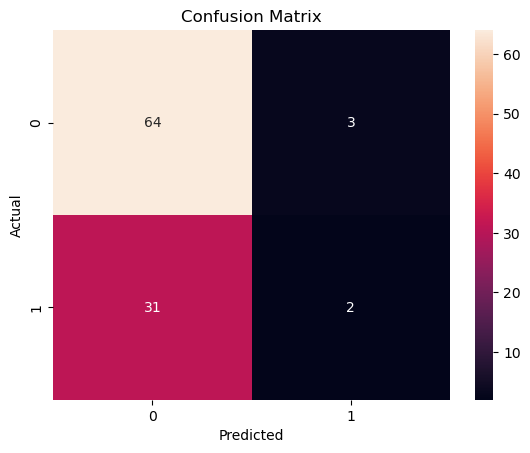

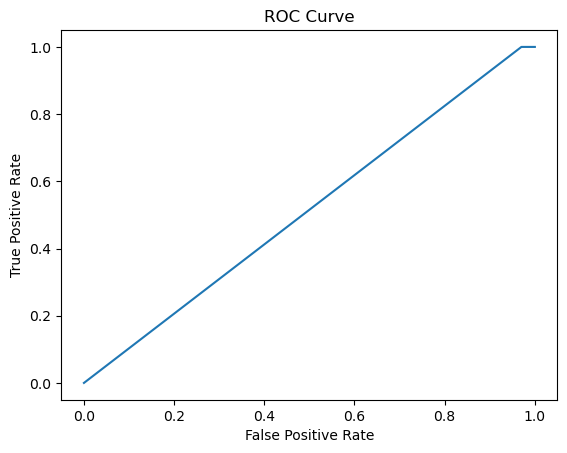

AUC_score: 0.51


In [5]:
# Evaluating model performance
# Your code for accuracy, precision and recall here
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)



print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")


# Confusion Matrix
# Your code here
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# Your code here to create the ROC curve

# AUC Score
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC_score: {auc_score:.2f}")